
# Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn

## Objectives
- Data preparation and cleaning
- Interactive visualizations with Matplotlib
- Visual analytics with Seaborn
- Comparative analysis between Matplotlib and Seaborn
- Documentation of insights and findings


In [1]:

# Install dependency if needed
# !pip install xlrd seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style="whitegrid")



## 1. Data Preparation
Load the US Superstore dataset and inspect its structure.


In [2]:

file_path = 'US Superstore data.xls'

# If xlrd is missing:
# !pip install xlrd

df = pd.read_excel(file_path)

print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:

# Dataset overview
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [4]:

# Missing values
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:

# Basic cleaning
df = df.drop_duplicates()

# Convert date columns if available
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col])

print('New shape:', df.shape)


New shape: (9994, 21)



## 2. Interactive Line Chart (Matplotlib)

Sales trends over the years.


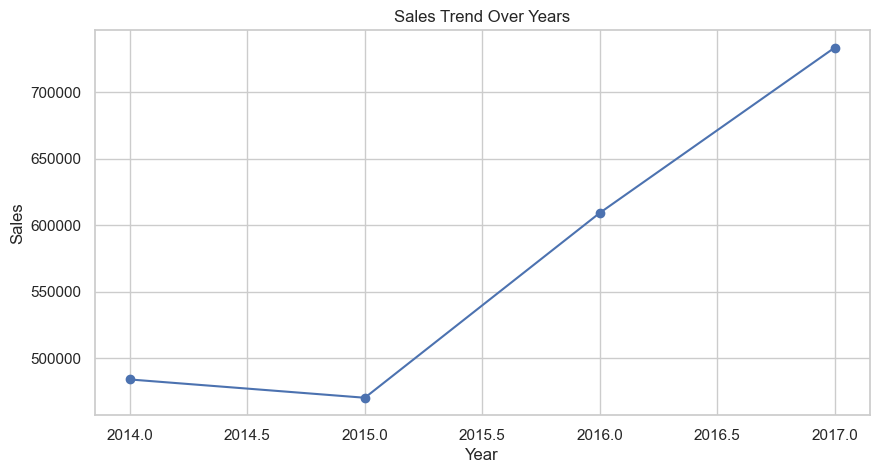

In [6]:

date_col = [c for c in df.columns if 'date' in c.lower()][0]
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]

sales_by_year = (
    df.groupby(df[date_col].dt.year)[sales_col]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sales_by_year[date_col], sales_by_year[sales_col], marker='o')
ax.set_title('Sales Trend Over Years')
ax.set_xlabel('Year')
ax.set_ylabel('Sales')
plt.show()



### Interactive Version


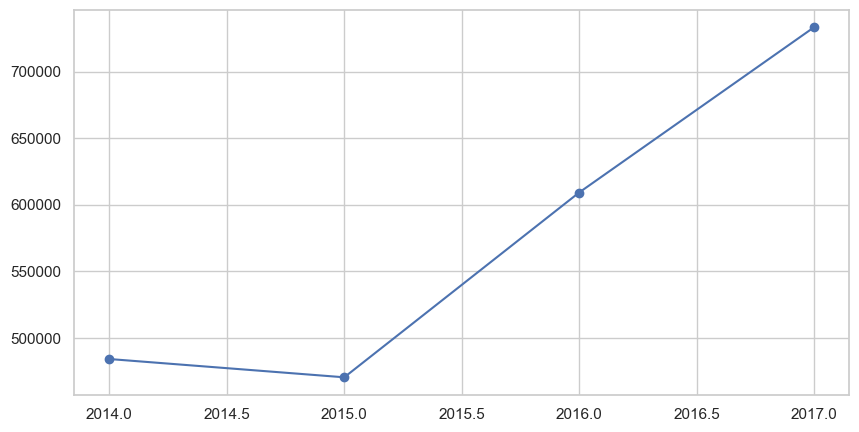

In [7]:

from matplotlib.widgets import Cursor

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sales_by_year[date_col], sales_by_year[sales_col], marker='o')

cursor = Cursor(ax, useblit=True, color='red', linewidth=1)
plt.show()



## Sales Distribution by Country


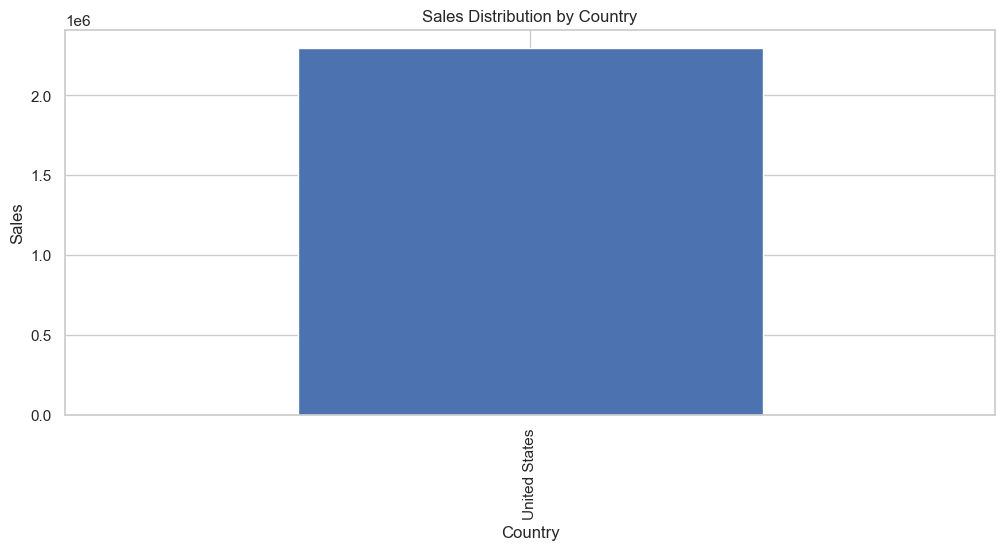

In [8]:

country_col = [c for c in df.columns if 'country' in c.lower()][0]

country_sales = (
    df.groupby(country_col)[sales_col]
    .sum()
    .sort_values(ascending=False)
)

country_sales.plot(kind='bar', figsize=(12,5))
plt.title('Sales Distribution by Country')
plt.ylabel('Sales')
plt.show()



## 3. Seaborn Visualizations
### Top 10 Products by Sales


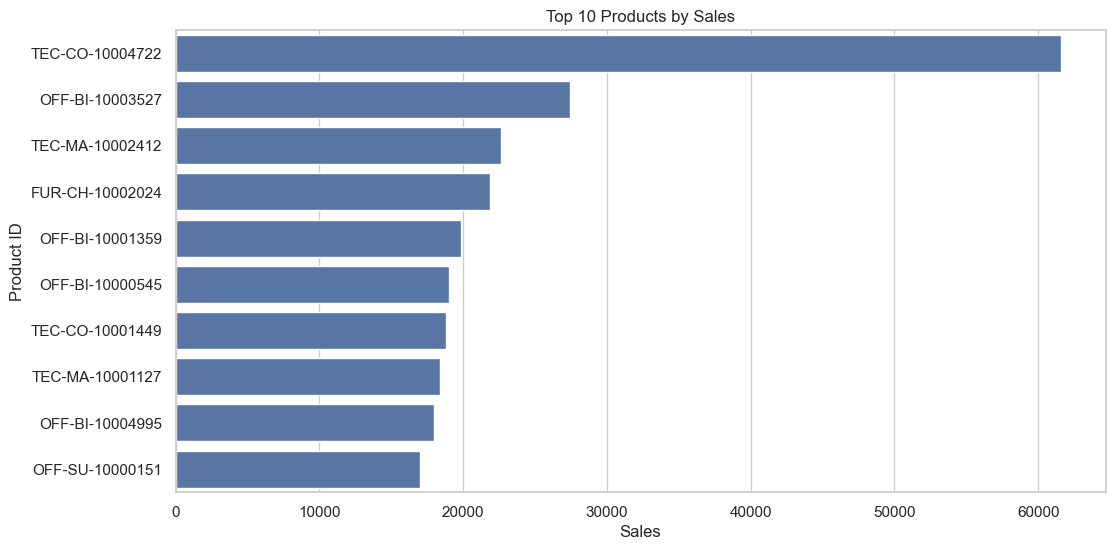

In [9]:

product_col = [c for c in df.columns if 'product' in c.lower()][0]

top_products = (
    df.groupby(product_col)[sales_col]
    .sum()
    .nlargest(10)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=top_products, x=sales_col, y=product_col)
plt.title('Top 10 Products by Sales')
plt.show()



### Profit vs Discount


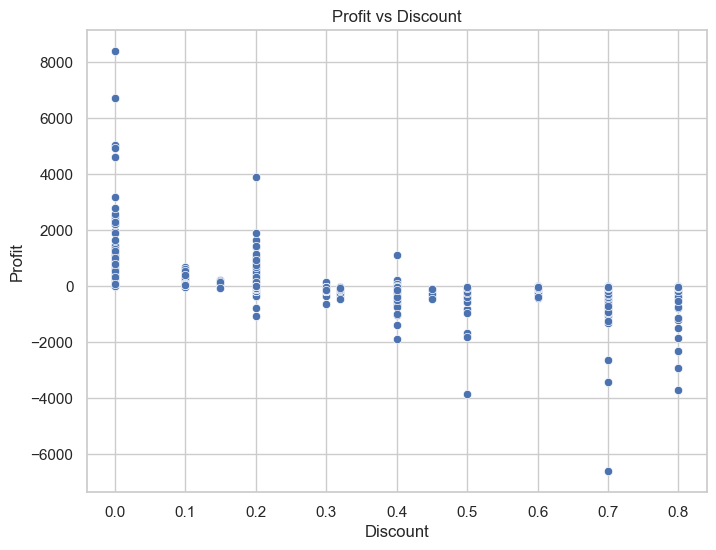

In [10]:

profit_col = [c for c in df.columns if 'profit' in c.lower()][0]
discount_col = [c for c in df.columns if 'discount' in c.lower()][0]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=discount_col, y=profit_col)
plt.title('Profit vs Discount')
plt.show()



# 4. Comparative Analysis

## Matplotlib
- Highly customizable.
- Suitable for interactive and low-level control.
- Better when fine-grained customization is required.

## Seaborn
- Faster for statistical graphics.
- Better default aesthetics.
- Requires less code for professional visualizations.

## Key Insights
1. Sales trends reveal business growth patterns.
2. Geographic distribution identifies high-performing markets.
3. Top-selling products contribute most revenue.
4. Higher discounts may negatively impact profit.



# 5. Conclusion

This notebook demonstrates:
- Data cleaning and preprocessing.
- Interactive visualizations with Matplotlib.
- Statistical visualizations with Seaborn.
- Business insights derived from the US Superstore dataset.
